# Background Estimation (`photutils.background`)

# Scalar Background and Noise Estimation

## Simple Statistics

In [1]:
from photutils.datasets import make_100gaussians_image 
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

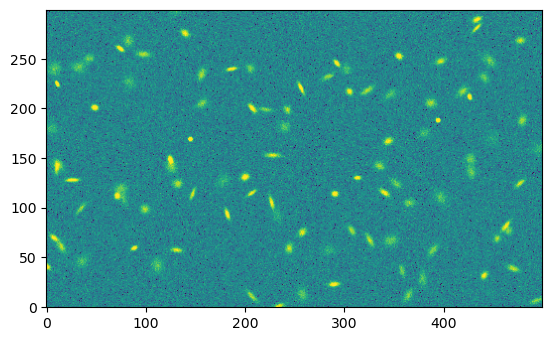

In [5]:
data = make_100gaussians_image()
    # Executa a função e armazena a imagem gerada em um array NumPy 2D chamado data.
    # A imagem tem dimensões padrão (geralmente 512×512 pixels) e contém as 100 fontes gaussianas mais um fundo com ruído.

norm = simple_norm(data, 'sqrt', percent=99.5)
    # normalização com:
    # sqrt -> usa a raiz quadrada como função de escala (realça partes escuras sem saturar as brilhantes)
    # percent=99.5 -> corta os 0.5% dos pixels mais intensos (outliers) para evitar que pontos muito brilhantes dominem a visualização.

fig, ax = plt.subplots()
ax.imshow(data, norm=norm, origin='lower')

In [3]:
import numpy as np
from astropy.stats import biweight_location

print(np.median(data))
print(biweight_location(data))

5.222396450477202
5.187556943476142


In [4]:
from astropy.stats import mad_std
print(mad_std(data))

2.1497096320053166


## Sigma Clipping Sources

In [7]:
from astropy.stats import sigma_clipped_stats

mean, median, std = sigma_clipped_stats(data, sigma=3.0)
print(np.array((mean, median, std)))

[5.19968673 5.15244174 2.09423739]


# Masking Sources 

In [13]:
from astropy.stats import sigma_clipped_stats, SigmaClip
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint

sigma_clip = SigmaClip(sigma=3.0, maxiters=10)
    # remover outliers 
    # sigma=3.0 -> pixels com valor > 3 desvios padrão da mediana são considerados outliers
    # maxiters=10 -> repete o processo no máximo 10 vezes (ou até que não tenha mais outliers)

threshold = detect_threshold(data, nsigma=2.0, sigma_clip=sigma_clip)
    # cálculo do limiar:
    # n_sigma=2.0 -> o limiar será = mediana do fundo + (2 × desvio padrão do fundo)
    # sigma_clip ->  estima a mediana e o desvio do fundo de forma robusta (sem ser afetado pelas fontes brilhantes)
    # retorna um array 2D com os valores de limiar para cada pixel

segment_img = detect_sources(data, threshold, npixels=10)
    # detecção das fontes:
    # threshold -> o limiar calculado acima.
    # n_pixels=10 > número mínimo de pixels conectados para considerar um grupo como fonte (evita ruído)
    # retorna um objeto SegmentImage onde cada fonte tem um número inteiro único (rótulo)

footprint = circular_footprint(radius=10)
    # cria uma máscara booleana circular de raio = 10 pixels
    # isso define a forma de como vai ser 'cercada 'cada fonte para extrair seus pixels

mask= segment_img.make_source_mask(footprint=footprint)
    # gera uma máscara booleana 2D onde:
    # se houver fontes detectadas, a máscara marca uma região circular (usando a footprint) ao redor de cada fonte
    # o objetivo é isolar as fontes para que possamos calcular estatísticas apenas do fundo (excluindo as fontes)

mean, median, std = sigma_clipped_stats(data, sigma=3.0, mask=mask)
    # estatísticas

print(np.array((mean, median, std)))

[5.00257401 4.99641799 1.97009566]


# 2D Background and Noise Estimation

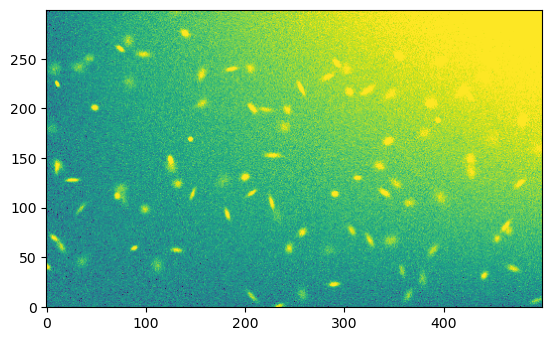

In [14]:
ny, nx = data.shape
y, x = np.mgrid[:ny, :nx]
gradient = x*y / 5000.0
data2 = data + gradient
fig, ax = plt.subplots()
ax.imshow(data2, norm=norm, origin='lower')

In [15]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground

sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg = Background2D(data2, (15, 15), filter_size=(3, 3),
                  sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)